In [ ]:
from datetime import timedelta
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from google.colab import auth
from google.cloud import bigquery, storage

# Authenticate and set up environment
auth.authenticate_user()
project_id = 'mcxrp-429811'
os.environ["GOOGLE_CLOUD_PROJECT"] = project_id
!gcloud config set project {project_id}

# Initialize BigQuery client
client = bigquery.Client(project=project_id)

# Initialize GCP Storage client with user_project parameter
storage_client = storage.Client(project=project_id)
bucket_name = 'cxr_embedding'
bucket = storage_client.bucket(bucket_name, user_project=project_id)

# Path to the final combined data CSV in your GCP bucket
final_path = 'final_combined_data1.csv'
final_combined_blob = bucket.blob(final_path)

Updated property [core/project].


In [1]:
# Download the final combined data CSV to a local temporary file
local_combined_data_path = '/tmp/final_combined_data.csv'
final_combined_blob.download_to_filename(local_combined_data_path)

# Load the final combined data CSV into a DataFrame
df = pd.read_csv(local_combined_data_path)
df.head()

NameError: name 'final_combined_blob' is not defined

In [ ]:
# Create a new column to categorize PEEP levels into high (>10) and low (<10) groups
df['peep_category'] = df['avg_peep'].apply(lambda x: 'high' if x > 10 else 'low')

# Display the distribution of the PEEP categories
df['peep_category'].value_counts()


peep_category
low     247
high    194
Name: count, dtype: int64

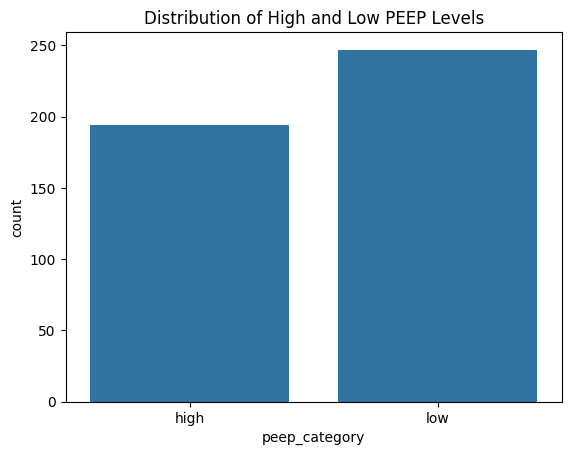

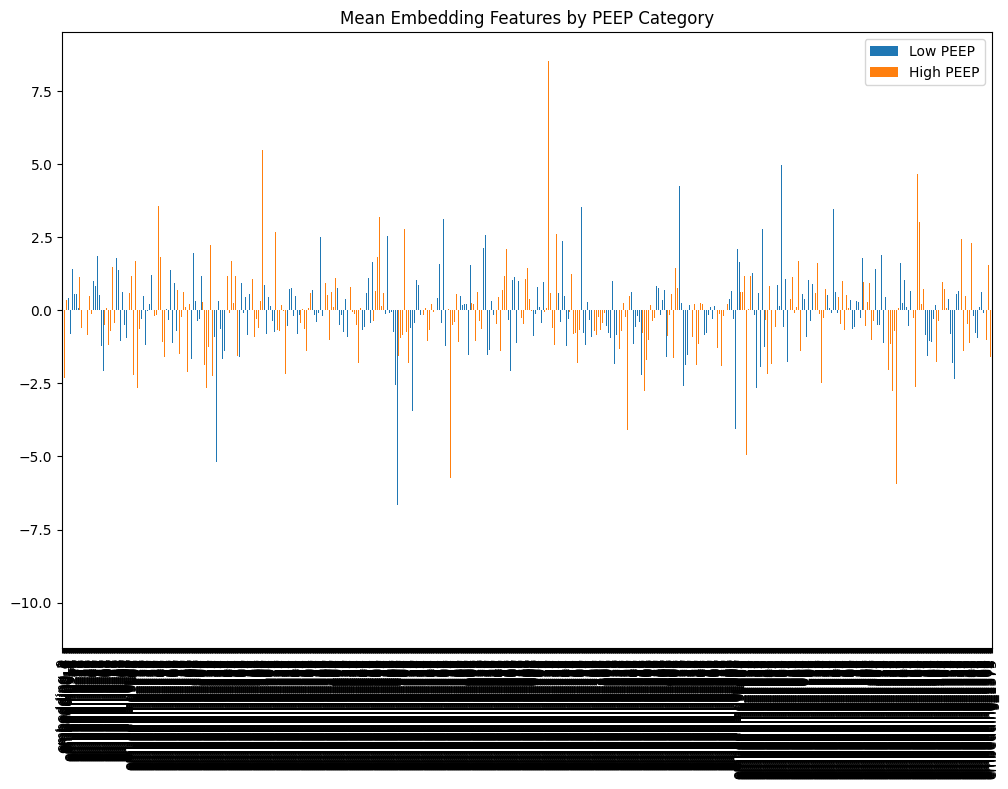

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the distribution of the PEEP categories
sns.countplot(data=df, x='peep_category')
plt.title('Distribution of High and Low PEEP Levels')
plt.show()

# Summary statistics of embedding features grouped by PEEP category
embedding_columns = [col for col in df.columns if col.startswith('embedding_')]
summary_stats = df.groupby('peep_category')[embedding_columns].mean().T
summary_stats.columns = ['Low PEEP', 'High PEEP']
summary_stats.plot(kind='bar', figsize=(12, 8))
plt.title('Mean Embedding Features by PEEP Category')
plt.show()


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Fit a regularized logistic regression model (Lasso)
log_reg = LogisticRegression(penalty='l1', solver='saga', max_iter=1000)
log_reg.fit(X_scaled, y)

# Get the coefficients and intercept
coef = log_reg.coef_[0]
intercept = log_reg.intercept_

# Print the classification report
y_pred = log_reg.predict(X_scaled)
print(classification_report(y, y_pred))

# Exponentiate the coefficients to interpret them as odds ratios
odds_ratios = np.exp(coef)
print("Odds Ratios:", odds_ratios)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       247
           1       1.00      1.00      1.00       194

    accuracy                           1.00       441
   macro avg       1.00      1.00      1.00       441
weighted avg       1.00      1.00      1.00       441

Odds Ratios: [0.91689061 1.         1.         ... 1.         1.02048461 1.        ]


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


   study_id  subject_id           study_datetime  \
0  52515667    10021487  2116-12-04 04:57:57.039   
1  56863750    10021927  2180-09-20 15:46:21.234   
2  57716752    10051043  2192-10-09 20:26:04.984   
3  58771416    10110764  2130-09-14 04:24:35.062   
4  50996857    10111112  2150-02-15 21:56:48.796   

                                path  \
0  files/p10/p10021487/s52515667.txt   
1  files/p10/p10021927/s56863750.txt   
2  files/p10/p10051043/s57716752.txt   
3  files/p10/p10110764/s58771416.txt   
4  files/p10/p10111112/s50996857.txt   

                                       dicom_id             timezero  \
0  9f7d78ea-3678f7f5-ad9613bc-7e4a779d-b7384021  2116-12-03 05:10:00   
1  00f6367a-bb53009c-e373833e-14201ddd-5edb8f5f  2180-09-20 16:33:00   
2  3abd6e9e-609cfd2a-2d3bda3a-09b013a0-80520892  2192-10-09 15:48:00   
3  dad5aca3-cd745760-e9ab74fa-5c07a3d1-75b4def3  2130-09-14 01:28:00   
4  9055c8de-1400b556-7de439ff-8d668884-122246cd  2150-02-15 21:48:00   

   icu_mort  

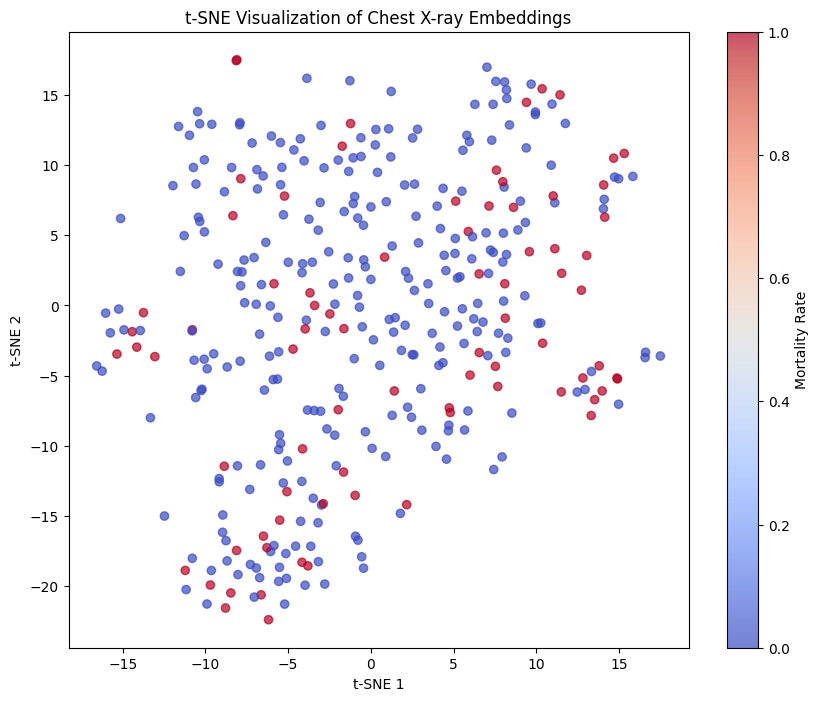

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


   subject_id  cluster
0    10021487        4
1    10021927        0
2    10051043        1
3    10110764        0
4    10111112        1


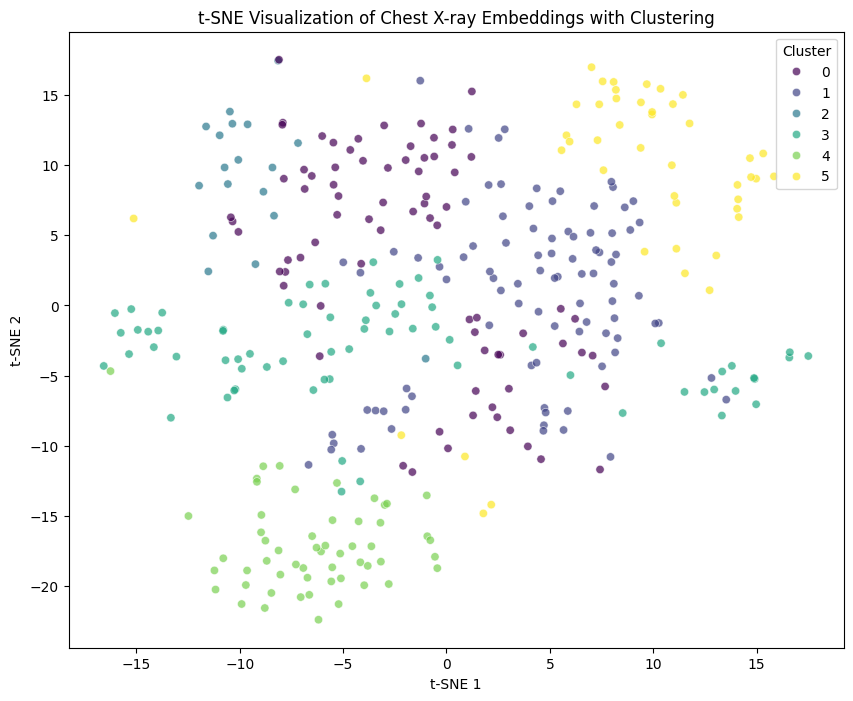

   cluster  icu_mort  count
0        0  0.116883     77
1        1  0.177778     90
2        2  0.111111     18
3        3  0.309859     71
4        4  0.272727     55
5        5  0.333333     45


In [ ]:

# Path to the filtered combined data CSV in your GCP bucket
filtered_data_path = 'filtered_combined_data.csv'
filtered_blob = bucket.blob(filtered_data_path)

# Download the filtered combined data CSV to a local temporary file
local_filtered_data_path = '/tmp/filtered_combined_data.csv'
filtered_blob.download_to_filename(local_filtered_data_path)

# Load the filtered combined data CSV into a DataFrame
df = pd.read_csv(local_filtered_data_path)

# Display the first few rows of the dataframe to verify the data
print(df.head())

# First, let's do PCA
from sklearn.decomposition import PCA

# Extract embedding vectors
embedding_columns = [col for col in df.columns if col.startswith('embedding_')]
embeddings = df[embedding_columns]

# Apply PCA
pca = PCA(n_components=50)  # Reduce to 50 components or adjust based on explained variance
embeddings_pca = pca.fit_transform(embeddings)

# Add PCA components to the dataframe
for i in range(embeddings_pca.shape[1]):
    df[f'pca_{i+1}'] = embeddings_pca[:, i]

# Display the explained variance ratio
print(pca.explained_variance_ratio_)

# Second, let's do t-SNE reduction
from sklearn.manifold import TSNE

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42)  # Reduce to 2 dimensions for visualization
embeddings_tsne = tsne.fit_transform(embeddings_pca)

# Add t-SNE components to the dataframe
df['tsne_1'] = embeddings_tsne[:, 0]
df['tsne_2'] = embeddings_tsne[:, 1]

# Display the first few rows of the dataframe with the new columns
print(df[['tsne_1', 'tsne_2']].head())

# Now, regression model!
import statsmodels.api as sm
import numpy as np

# Prepare the data for regression analysis
X = df[[f'pca_{i+1}' for i in range(50)]]
y = df['icu_mort']

# Add a constant to the independent variables
X = sm.add_constant(X)

# Fit the logistic regression model
model = sm.Logit(y, X)
result = model.fit()

# Display the summary of the regression analysis
print(result.summary())

# Exponentiate the coefficients to interpret them as odds ratios
odds_ratios = np.exp(result.params)
print(odds_ratios)

import matplotlib.pyplot as plt

# Plot t-SNE results
plt.figure(figsize=(10, 8))
plt.scatter(df['tsne_1'], df['tsne_2'], c=df['icu_mort'], cmap='coolwarm', alpha=0.7)
plt.colorbar(label='Mortality Rate')
plt.title('t-SNE Visualization of Chest X-ray Embeddings')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.show()

# Clustering
from sklearn.cluster import KMeans
import seaborn as sns

# Select the number of clusters
num_clusters = 6

# Perform K-means clustering on the PCA components
pca_components = df[[f'pca_{i+1}' for i in range(50)]]
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
df['cluster'] = kmeans.fit_predict(pca_components)

# Add the cluster labels to the dataframe
df['cluster'] = kmeans.labels_

# Display the first few rows to verify the clustering
print(df[['subject_id', 'cluster']].head())

# Plot t-SNE results with cluster labels
plt.figure(figsize=(10, 8))
sns.scatterplot(x='tsne_1', y='tsne_2', hue='cluster', palette='viridis', data=df, alpha=0.7)
plt.title('t-SNE Visualization of Chest X-ray Embeddings with Clustering')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(title='Cluster')
plt.show()

# Calculate the mean mortality rate for each cluster
cluster_analysis = df.groupby('cluster').agg({
    'icu_mort': 'mean',
    'subject_id': 'count'
}).rename(columns={'subject_id': 'count'}).reset_index()

print(cluster_analysis)


In [ ]:
from datetime import timedelta
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from google.colab import auth
from google.cloud import bigquery, storage

# Authenticate and set up environment
auth.authenticate_user()
project_id = 'mcxrp-429811'
os.environ["GOOGLE_CLOUD_PROJECT"] = project_id
!gcloud config set project {project_id}

# Initialize BigQuery client
client = bigquery.Client(project=project_id)

# Initialize GCP Storage client with user_project parameter
storage_client = storage.Client(project=project_id)
bucket_name = 'cxr_embedding'
bucket = storage_client.bucket(bucket_name, user_project=project_id)

# Path to the final combined data CSV in your GCP bucket
final_path = 'final_combined_data1.csv'
final_combined_blob = bucket.blob(final_path)

Updated property [core/project].


In [ ]:
# Download the final combined data CSV to a local temporary file
local_combined_data_path = '/tmp/final_combined_data.csv'
final_combined_blob.download_to_filename(local_combined_data_path)

# Load the final combined data CSV into a DataFrame
df = pd.read_csv(local_combined_data_path)
df.head()

,study_id,subject_id,study_datetime,path,dicom_id,timezero,icu_mort,avg_peep,time_diff,embedding_0,...,embedding_1366,embedding_1367,embedding_1368,embedding_1369,embedding_1370,embedding_1371,embedding_1372,embedding_1373,embedding_1374,embedding_1375
0,52515667,10021487,2116-12-04 04:57:57.039,files/p10/p10021487/s52515667.txt,9f7d78ea-3678f7f5-ad9613bc-7e4a779d-b7384021,2116-12-03 05:10:00,0,10.000000,0 days 23:47:57.039000,0.321410,...,0.534237,-2.750094,1.143226,1.435934,1.774311,2.893189,1.400407,-1.003595,-0.724755,-1.416682
1,56863750,10021927,2180-09-20 15:46:21.234,files/p10/p10021927/s56863750.txt,00f6367a-bb53009c-e373833e-14201ddd-5edb8f5f,2180-09-20 16:33:00,1,12.400000,0 days 00:46:38.766000,-0.876179,...,0.020621,-0.782480,0.022555,0.940223,1.454747,0.773782,1.420921,-2.257564,1.126008,-0.909788
2,57716752,10051043,2192-10-09 20:26:04.984,files/p10/p10051043/s57716752.txt,3abd6e9e-609cfd2a-2d3bda3a-09b013a0-80520892,2192-10-09 15:48:00,0,9.375000,0 days 04:38:04.984000,-1.135697,...,-0.425739,-0.837193,-0.428362,0.732233,1.128722,0.544618,1.063945,-1.826014,0.829188,0.179338
3,52433992,10104308,2160-10-03 14:16:56.484,files/p10/p10104308/s52433992.txt,40bac007-fb508cc1-b30a2883-ddcd7ff5-8b3289b5,2159-09-03 10:33:00,0,8.085714,396 days 03:43:56.484000,0.276103,...,0.635640,-0.059494,1.881543,-0.074930,1.251061,2.480877,0.527934,-0.914338,1.440813,-0.968126
4,58771416,10110764,2130-09-14 04:24:35.062,files/p10/p10110764/s58771416.txt,dad5aca3-cd745760-e9ab74fa-5c07a3d1-75b4def3,2130-09-14 01:28:00,0,9.688889,0 days 02:56:35.062000,-0.987584,...,0.153718,-1.049363,0.761723,1.013380,1.579533,0.826246,0.742138,-1.636520,1.260924,-1.266616


In [2]:
import cv2
import numpy as np

# load image as grayscale
img = cv2.imread('xray_chest.jpg')

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# threshold
thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)[1]
hh, ww = thresh.shape

# make bottom 2 rows black where they are white the full width of the image
thresh[hh-3:hh, 0:ww] = 0

# get bounds of white pixels
white = np.where(thresh==255)
xmin, ymin, xmax, ymax = np.min(white[1]), np.min(white[0]), np.max(white[1]), np.max(white[0])
print(xmin,xmax,ymin,ymax)

# crop the image at the bounds adding back the two blackened rows at the bottom
crop = img[ymin:ymax+3, xmin:xmax]

# save resulting masked image
cv2.imwrite('xray_chest_thresh.jpg', thresh)
cv2.imwrite('xray_chest_crop.jpg', crop)

# display result
cv2.imshow("thresh", thresh)
cv2.imshow("crop", crop)
cv2.waitKey(0)
cv2.destroyAllWindows()

error: OpenCV(4.10.0) /io/opencv/modules/imgproc/src/color.cpp:196: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'
